In [1]:
!pip install gymnasium minigrid torch numpy matplotlib pandas tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.7/136.7 kB 3.0 MB/s eta 0:00:00


In [2]:
import copy
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import trange

import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Categorical
from torch.utils.data import TensorDataset, DataLoader

import gymnasium as gym
from minigrid.wrappers import FullyObsWrapper
from minigrid.core.constants import OBJECT_TO_IDX, COLOR_TO_IDX

In [3]:
def safe_seed(seed):
    return None if seed is None else int(seed)

def set_seed(seed=42):
    seed = safe_seed(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cpu


In [4]:
class FlatFourRoomsObs(gym.ObservationWrapper):
    def __init__(self, env):
        super().__init__(env)
        obs_shape = env.observation_space["image"].shape
        flat_dim = int(np.prod(obs_shape))
        self.observation_space = gym.spaces.Box(
            low=0.0, high=255.0, shape=(flat_dim,), dtype=np.float32
        )

    def observation(self, obs):
        return obs["image"].astype(np.float32).reshape(-1) / 255.0

def make_env(seed=42, render_mode=None):
    seed = safe_seed(seed)
    env = gym.make("MiniGrid-FourRooms-v0", render_mode=render_mode, max_steps=100)
    env = FullyObsWrapper(env)
    env = FlatFourRoomsObs(env)
    env.reset(seed=seed)
    env.action_space.seed(seed)
    return env

def get_flat_obs_from_env(env):
    """
    Build the current full observation directly from env state.
    Needed for Poly-PPO branch rollouts from copied env snapshots.
    """
    grid = env.unwrapped.grid.encode()
    ax, ay = env.unwrapped.agent_pos
    grid[ax, ay] = np.array([
        OBJECT_TO_IDX["agent"],
        COLOR_TO_IDX["red"],
        env.unwrapped.agent_dir
    ], dtype=np.int64)
    return grid.astype(np.float32).reshape(-1) / 255.0

test_env = make_env()
obs, _ = test_env.reset(seed=42)
print("obs shape:", obs.shape)
print("n actions:", test_env.action_space.n)

obs shape: (1083,)
n actions: 7


In [5]:
class ActorCritic(nn.Module):
    def __init__(self, obs_dim, act_dim, hidden_dim=256):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        self.policy_head = nn.Linear(hidden_dim, act_dim)
        self.value_head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        z = self.shared(x)
        logits = self.policy_head(z)
        value = self.value_head(z).squeeze(-1)
        return logits, value

    def get_dist_value(self, x):
        logits, value = self.forward(x)
        dist = Categorical(logits=logits)
        return dist, value

In [6]:
def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

def clone_state_dict(model):
    return copy.deepcopy(model.state_dict())

def discount_cumsum(rewards, gamma=0.99):
    out = np.zeros_like(rewards, dtype=np.float32)
    running = 0.0
    for i in reversed(range(len(rewards))):
        running = rewards[i] + gamma * running
        out[i] = running
    return out

def compute_gae(rewards, values, dones, next_value, gamma=0.99, lam=0.95):
    T = len(rewards)
    advantages = np.zeros(T, dtype=np.float32)
    lastgaelam = 0.0
    for t in reversed(range(T)):
        if t == T - 1:
            nextnonterminal = 1.0 - dones[t]
            nextvalues = next_value
        else:
            nextnonterminal = 1.0 - dones[t]
            nextvalues = values[t + 1]
        delta = rewards[t] + gamma * nextvalues * nextnonterminal - values[t]
        lastgaelam = delta + gamma * lam * nextnonterminal * lastgaelam
        advantages[t] = lastgaelam
    returns = advantages + values
    return advantages, returns

def evaluate_agent(model, episodes=100, seed=123):
    env = make_env(seed=seed)
    model.eval()
    rewards = []
    successes = []

    with torch.no_grad():
        for ep in range(episodes):
            obs, _ = env.reset(seed=safe_seed(seed + ep))
            done = False
            total_reward = 0.0
            success = 0

            while not done:
                obs_t = to_tensor(obs).unsqueeze(0)
                dist, _ = model.get_dist_value(obs_t)
                action = torch.argmax(dist.probs, dim=-1).item()

                obs, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated
                total_reward += reward

                if terminated and reward > 0:
                    success = 1

            rewards.append(total_reward)
            successes.append(success)

    return {
        "avg_reward": float(np.mean(rewards)),
        "success_rate": 100.0 * float(np.mean(successes))
    }

In [7]:
DIR_TO_VEC = {
    0: np.array((1, 0)),   # right
    1: np.array((0, 1)),   # down
    2: np.array((-1, 0)),  # left
    3: np.array((0, -1)),  # up
}

LEFT = 0
RIGHT = 1
FORWARD = 2

def find_goal_pos(env):
    grid = env.unwrapped.grid
    for x in range(env.unwrapped.width):
        for y in range(env.unwrapped.height):
            cell = grid.get(x, y)
            if cell is not None and cell.type == "goal":
                return (x, y)
    return None

def can_move_to(env, x, y):
    if x < 0 or y < 0 or x >= env.unwrapped.width or y >= env.unwrapped.height:
        return False
    cell = env.unwrapped.grid.get(x, y)
    if cell is None:
        return True
    return cell.can_overlap()

def next_state_from_action(env, state, action):
    x, y, d = state
    if action == LEFT:
        return (x, y, (d - 1) % 4)
    elif action == RIGHT:
        return (x, y, (d + 1) % 4)
    elif action == FORWARD:
        dx, dy = DIR_TO_VEC[d]
        nx, ny = x + dx, y + dy
        if can_move_to(env, nx, ny):
            return (nx, ny, d)
        return (x, y, d)
    else:
        raise ValueError("Unsupported action for expert planner.")

def shortest_path_actions(env):
    goal = find_goal_pos(env)
    if goal is None:
        return None

    start = (
        int(env.unwrapped.agent_pos[0]),
        int(env.unwrapped.agent_pos[1]),
        int(env.unwrapped.agent_dir)
    )

    from collections import deque
    q = deque([start])
    parent = {start: None}
    parent_action = {start: None}

    while q:
        s = q.popleft()
        if (s[0], s[1]) == goal:
            actions = []
            cur = s
            while parent[cur] is not None:
                actions.append(parent_action[cur])
                cur = parent[cur]
            return list(reversed(actions))

        for a in [LEFT, RIGHT, FORWARD]:
            ns = next_state_from_action(env, s, a)
            if ns not in parent:
                parent[ns] = s
                parent_action[ns] = a
                q.append(ns)

    return None

In [8]:
def generate_expert_dataset(num_episodes=3000, seed=42):
    obs_list = []
    action_list = []

    successful_eps = 0
    attempted = 0
    cur_seed = safe_seed(seed)

    while successful_eps < num_episodes:
        attempted += 1
        env = make_env(seed=safe_seed(cur_seed + attempted))
        obs, _ = env.reset(seed=safe_seed(cur_seed + attempted))

        expert_actions = shortest_path_actions(env)
        if expert_actions is None or len(expert_actions) == 0:
            continue

        for a in expert_actions:
            obs_list.append(obs.copy())
            action_list.append(int(a))
            obs, _, terminated, truncated, _ = env.step(a)
            if terminated or truncated:
                break

        successful_eps += 1
        if successful_eps % 500 == 0:
            print(f"generated {successful_eps}/{num_episodes} expert episodes")

    X = np.array(obs_list, dtype=np.float32)
    y = np.array(action_list, dtype=np.int64)
    return X, y

X_demo, y_demo = generate_expert_dataset(num_episodes=3000, seed=42)
print(X_demo.shape, y_demo.shape)

generated 500/3000 expert episodes
generated 1000/3000 expert episodes
generated 1500/3000 expert episodes
generated 2000/3000 expert episodes
generated 2500/3000 expert episodes
generated 3000/3000 expert episodes
(47900, 1083) (47900,)


In [9]:
def pretrain_behavior_cloning(
    X, y,
    epochs=15,
    batch_size=256,
    lr=1e-3,
    seed=42
):
    seed = safe_seed(seed)
    set_seed(seed)

    env = make_env(seed=seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    model = ActorCritic(obs_dim, act_dim).to(device)

    dataset = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.long)
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    ce_loss = nn.CrossEntropyLoss()

    hist = []

    for epoch in trange(epochs, desc="Behavior Cloning"):
        model.train()
        losses = []

        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits, _ = model(xb)
            loss = ce_loss(logits, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            losses.append(loss.item())

        metrics = evaluate_agent(model, episodes=50, seed=safe_seed(seed + 1000))
        hist.append({
            "epoch": epoch + 1,
            "bc_loss": float(np.mean(losses)),
            "avg_reward": metrics["avg_reward"],
            "success_rate": metrics["success_rate"]
        })

    return model, pd.DataFrame(hist)

pretrained_model, bc_hist = pretrain_behavior_cloning(X_demo, y_demo, epochs=15, batch_size=256, lr=1e-3, seed=42)
pretrained_metrics = evaluate_agent(pretrained_model, episodes=100, seed=999)
print("Pretrained:", pretrained_metrics)
pretrained_state = clone_state_dict(pretrained_model)

Behavior Cloning:   0%|          | 0/15 [00:00<?, ?it/s]

Pretrained: {'avg_reward': 0.01964, 'success_rate': 2.0}


In [10]:
def collect_episode(env, model):
    obs, _ = env.reset()
    done = False

    observations = []
    actions = []
    logprobs = []
    rewards = []
    dones = []
    values = []

    while not done:
        obs_t = to_tensor(obs).unsqueeze(0)
        dist, value = model.get_dist_value(obs_t)
        action = dist.sample()
        logprob = dist.log_prob(action)

        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        observations.append(obs)
        actions.append(action.item())
        logprobs.append(logprob.item())
        rewards.append(reward)
        dones.append(float(done))
        values.append(value.item())

        obs = next_obs

    return {
        "obs": np.array(observations, dtype=np.float32),
        "actions": np.array(actions, dtype=np.int64),
        "logprobs": np.array(logprobs, dtype=np.float32),
        "rewards": np.array(rewards, dtype=np.float32),
        "dones": np.array(dones, dtype=np.float32),
        "values": np.array(values, dtype=np.float32),
    }

In [11]:
def train_reinforce(
    total_episodes=1000,
    gamma=0.99,
    lr=1e-4,
    seed=42,
    init_state_dict=None
):
    seed = safe_seed(seed)
    env = make_env(seed=seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    model = ActorCritic(obs_dim, act_dim).to(device)
    if init_state_dict is not None:
        model.load_state_dict(copy.deepcopy(init_state_dict))

    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for ep in trange(total_episodes, desc="REINFORCE"):
        traj = collect_episode(env, model)

        returns = discount_cumsum(traj["rewards"], gamma=gamma)
        returns_t = to_tensor(returns)
        obs_t = to_tensor(traj["obs"])
        act_t = torch.tensor(traj["actions"], dtype=torch.long, device=device)

        dist, _ = model.get_dist_value(obs_t)
        logprobs = dist.log_prob(act_t)

        loss = -(logprobs * returns_t).mean()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (ep + 1) % 50 == 0:
            metrics = evaluate_agent(model, episodes=50, seed=safe_seed(seed + 1000))
            history.append({
                "step": ep + 1,
                "avg_reward": metrics["avg_reward"],
                "success_rate": metrics["success_rate"]
            })

    return model, pd.DataFrame(history)

In [12]:
def collect_ppo_batch(
    env,
    model,
    steps_per_batch=1024,
    gamma=0.99,
    lam=0.95,
    save_snapshots=False,
    max_snapshots=8
):
    obs_buf, act_buf, logp_buf = [], [], []
    rew_buf, done_buf, val_buf = [], [], []
    snapshots = []

    obs, _ = env.reset()
    ep_rewards = []
    episode_returns = []

    snapshot_interval = max(1, steps_per_batch // max_snapshots)

    for t in range(steps_per_batch):
        if save_snapshots and (t % snapshot_interval == 0) and (len(snapshots) < max_snapshots):
            # save env state BEFORE action for Poly-PPO rollout branching
            snapshots.append((len(obs_buf), copy.deepcopy(env)))

        obs_t = to_tensor(obs).unsqueeze(0)
        with torch.no_grad():
            dist, value = model.get_dist_value(obs_t)
            action = dist.sample()
            logprob = dist.log_prob(action)

        next_obs, reward, terminated, truncated, _ = env.step(action.item())
        done = terminated or truncated

        obs_buf.append(obs)
        act_buf.append(action.item())
        logp_buf.append(logprob.item())
        rew_buf.append(reward)
        done_buf.append(float(done))
        val_buf.append(value.item())

        ep_rewards.append(reward)
        obs = next_obs

        if done:
            episode_returns.append(sum(ep_rewards))
            ep_rewards = []
            obs, _ = env.reset()

    with torch.no_grad():
        next_value = model.get_dist_value(to_tensor(obs).unsqueeze(0))[1].item()

    advantages, returns = compute_gae(
        rewards=np.array(rew_buf, dtype=np.float32),
        values=np.array(val_buf, dtype=np.float32),
        dones=np.array(done_buf, dtype=np.float32),
        next_value=next_value,
        gamma=gamma,
        lam=lam
    )

    return {
        "obs": np.array(obs_buf, dtype=np.float32),
        "actions": np.array(act_buf, dtype=np.int64),
        "logprobs": np.array(logp_buf, dtype=np.float32),
        "advantages": advantages,
        "returns": returns,
        "values": np.array(val_buf, dtype=np.float32),
        "episode_returns": episode_returns,
        "snapshots": snapshots
    }

In [13]:
def train_ppo(
    total_updates=200,
    steps_per_batch=1024,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    lr=3e-4,
    update_epochs=4,
    minibatch_size=128,
    vf_coef=0.5,
    ent_coef=0.01,
    max_grad_norm=0.5,
    seed=42,
    init_state_dict=None
):
    seed = safe_seed(seed)
    env = make_env(seed=seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    model = ActorCritic(obs_dim, act_dim).to(device)
    if init_state_dict is not None:
        model.load_state_dict(copy.deepcopy(init_state_dict))

    optimizer = optim.Adam(model.parameters(), lr=lr)
    history = []

    for update in trange(total_updates, desc="PPO"):
        batch = collect_ppo_batch(env, model, steps_per_batch, gamma, lam)

        obs_t = to_tensor(batch["obs"])
        act_t = torch.tensor(batch["actions"], dtype=torch.long, device=device)
        old_logp_t = to_tensor(batch["logprobs"])
        adv_t = to_tensor(batch["advantages"])
        ret_t = to_tensor(batch["returns"])

        adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        n = len(obs_t)
        idxs = np.arange(n)

        for _ in range(update_epochs):
            np.random.shuffle(idxs)
            for start in range(0, n, minibatch_size):
                mb = idxs[start:start + minibatch_size]

                dist, value = model.get_dist_value(obs_t[mb])
                new_logp = dist.log_prob(act_t[mb])
                entropy = dist.entropy().mean()

                ratio = torch.exp(new_logp - old_logp_t[mb])
                unclipped = ratio * adv_t[mb]
                clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_t[mb]
                policy_loss = -torch.min(unclipped, clipped).mean()

                value_loss = ((value - ret_t[mb]) ** 2).mean()
                loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()

        if (update + 1) % 10 == 0:
            metrics = evaluate_agent(model, episodes=50, seed=safe_seed(seed + 1000))
            history.append({
                "step": update + 1,
                "avg_reward": metrics["avg_reward"],
                "success_rate": metrics["success_rate"]
            })

    return model, pd.DataFrame(history)

In [14]:
def get_room_id(pos):
    x, y = pos
    # FourRooms is 19x19 with a central cross around x=9 or y=9.
    # Ignore corridor cells on the central lines.
    if x < 9 and y < 9:
        return 0
    if x > 9 and y < 9:
        return 1
    if x < 9 and y > 9:
        return 2
    if x > 9 and y > 9:
        return 3
    return None

def rollout_from_snapshot(snapshot_env, model, max_steps=100):
    env = copy.deepcopy(snapshot_env)
    obs = get_flat_obs_from_env(env)
    done = False

    rewards = []
    visited_positions = []
    pairs = []

    while not done and len(rewards) < max_steps:
        pos = tuple(env.unwrapped.agent_pos)
        visited_positions.append(pos)

        obs_t = to_tensor(obs).unsqueeze(0)
        with torch.no_grad():
            dist, _ = model.get_dist_value(obs_t)
            action = dist.sample().item()

        pairs.append((obs.copy(), action))
        _, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        rewards.append(reward)

        if not done:
            obs = get_flat_obs_from_env(env)

    visited_rooms = frozenset(
        rid for rid in [get_room_id(p) for p in visited_positions] if rid is not None
    )

    return {
        "return": float(np.sum(rewards)),
        "visited_rooms": visited_rooms,
        "pairs": pairs
    }

def diversity_score(traj_group):
    room_sets = [t["visited_rooms"] for t in traj_group]
    unique_count = len(set(room_sets))
    return unique_count / len(room_sets)

def normalize_returns(returns):
    returns = np.array(returns, dtype=np.float32)
    if returns.max() - returns.min() < 1e-8:
        return np.ones_like(returns)
    return (returns - returns.min()) / (returns.max() - returns.min())

In [15]:
def collect_polyppo_batch(
    env,
    model,
    steps_per_batch=1024,
    gamma=1.0,
    lam=0.95,
    N=8,
    n=4,
    M=4,
    W=5,
    seed=42
):
    batch = collect_ppo_batch(
        env,
        model,
        steps_per_batch=steps_per_batch,
        gamma=gamma,
        lam=lam,
        save_snapshots=True,
        max_snapshots=8
    )

    poly_adv = np.array(batch["advantages"], copy=True)

    for idx, snapshot_env in batch["snapshots"]:
        vines = []
        for _ in range(N):
            vine = rollout_from_snapshot(snapshot_env, model, max_steps=100)
            vines.append(vine)

        all_returns = [v["return"] for v in vines]
        norm_returns = normalize_returns(all_returns)

        enriched = []
        for vine, r in zip(vines, norm_returns):
            enriched.append({
                "return_norm": float(r),
                "visited_rooms": vine["visited_rooms"],
                "pairs": vine["pairs"]
            })

        if len(enriched) < n:
            continue

        group_scores = []
        for _ in range(M):
            chosen = random.sample(enriched, n)
            d = diversity_score(chosen)
            avg_ret = np.mean([x["return_norm"] for x in chosen])
            score = avg_ret * d
            group_scores.append(score)

        baseline = float(np.mean(group_scores))
        poly_signal = float(np.max(group_scores) - baseline)

        for j in range(idx, min(idx + W, len(poly_adv))):
            poly_adv[j] = poly_signal

    batch["advantages"] = poly_adv
    batch["returns"] = batch["values"] + poly_adv
    return batch

In [16]:
def train_polyppo(
    total_updates=200,
    steps_per_batch=1024,
    gamma=1.0,
    lam=0.95,
    clip_eps=0.2,
    actor_lr=1e-5,
    critic_lr=1e-4,
    update_epochs=2,
    minibatch_size=64,
    vf_coef=0.5,
    ent_coef=0.01,
    max_grad_norm=0.5,
    N=8,
    n=4,
    M=4,
    W=5,
    seed=42,
    init_state_dict=None
):
    seed = safe_seed(seed)
    env = make_env(seed=seed)
    obs_dim = env.observation_space.shape[0]
    act_dim = env.action_space.n

    model = ActorCritic(obs_dim, act_dim).to(device)
    if init_state_dict is not None:
        model.load_state_dict(copy.deepcopy(init_state_dict))

    optimizer = optim.Adam([
        {"params": list(model.shared.parameters()) + list(model.policy_head.parameters()), "lr": actor_lr},
        {"params": model.value_head.parameters(), "lr": critic_lr},
    ])

    history = []

    for update in trange(total_updates, desc="Poly-PPO"):
        batch = collect_polyppo_batch(
            env=env,
            model=model,
            steps_per_batch=steps_per_batch,
            gamma=gamma,
            lam=lam,
            N=N,
            n=n,
            M=M,
            W=W,
            seed=safe_seed(seed + update)
        )

        obs_t = to_tensor(batch["obs"])
        act_t = torch.tensor(batch["actions"], dtype=torch.long, device=device)
        old_logp_t = to_tensor(batch["logprobs"])
        adv_t = to_tensor(batch["advantages"])
        ret_t = to_tensor(batch["returns"])

        adv_t = (adv_t - adv_t.mean()) / (adv_t.std() + 1e-8)

        n_samples = len(obs_t)
        idxs = np.arange(n_samples)

        for _ in range(update_epochs):
            np.random.shuffle(idxs)
            for start in range(0, n_samples, minibatch_size):
                mb = idxs[start:start + minibatch_size]

                dist, value = model.get_dist_value(obs_t[mb])
                new_logp = dist.log_prob(act_t[mb])
                entropy = dist.entropy().mean()

                ratio = torch.exp(new_logp - old_logp_t[mb])
                unclipped = ratio * adv_t[mb]
                clipped = torch.clamp(ratio, 1 - clip_eps, 1 + clip_eps) * adv_t[mb]
                policy_loss = -torch.min(unclipped, clipped).mean()

                value_loss = ((value - ret_t[mb]) ** 2).mean()
                loss = policy_loss + vf_coef * value_loss - ent_coef * entropy

                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_grad_norm)
                optimizer.step()

        if (update + 1) % 10 == 0:
            metrics = evaluate_agent(model, episodes=50, seed=safe_seed(seed + 1000))
            history.append({
                "step": update + 1,
                "avg_reward": metrics["avg_reward"],
                "success_rate": metrics["success_rate"]
            })

    return model, pd.DataFrame(history)

In [17]:
reinforce_model, reinforce_hist = train_reinforce(
    total_episodes=1000,
    gamma=0.99,
    lr=1e-4,
    seed=42,
    init_state_dict=pretrained_state
)

ppo_model, ppo_hist = train_ppo(
    total_updates=200,
    steps_per_batch=1024,
    gamma=0.99,
    lam=0.95,
    clip_eps=0.2,
    lr=3e-4,
    update_epochs=4,
    minibatch_size=128,
    seed=42,
    init_state_dict=pretrained_state
)

polyppo_model, polyppo_hist = train_polyppo(
    total_updates=200,
    steps_per_batch=1024,
    gamma=1.0,
    lam=0.95,
    clip_eps=0.2,
    actor_lr=1e-5,
    critic_lr=1e-4,
    update_epochs=2,
    minibatch_size=64,
    N=8,
    n=4,
    M=4,
    W=5,
    seed=42,
    init_state_dict=pretrained_state
)

REINFORCE:   0%|          | 0/1000 [00:00<?, ?it/s]

PPO:   0%|          | 0/200 [00:00<?, ?it/s]

Poly-PPO:   0%|          | 0/200 [00:00<?, ?it/s]

In [18]:
paper_targets = pd.DataFrame([
    {"Algorithm": "Pretrained", "Paper Reward": 0.469, "Paper Success Rate (%)": 70.4},
    {"Algorithm": "REINFORCE", "Paper Reward": 0.639, "Paper Success Rate (%)": 89.6},
    {"Algorithm": "PPO", "Paper Reward": 0.618, "Paper Success Rate (%)": 89.2},
    {"Algorithm": "Poly-PPO", "Paper Reward": 0.666, "Paper Success Rate (%)": 92.4},
])

results = []

pretrained_eval = evaluate_agent(pretrained_model, episodes=100, seed=999)
results.append({
    "Algorithm": "Pretrained",
    "Average Reward": pretrained_eval["avg_reward"],
    "Success Rate (%)": pretrained_eval["success_rate"]
})

for name, model in [
    ("REINFORCE", reinforce_model),
    ("PPO", ppo_model),
    ("Poly-PPO", polyppo_model),
]:
    metrics = evaluate_agent(model, episodes=100, seed=999)
    results.append({
        "Algorithm": name,
        "Average Reward": metrics["avg_reward"],
        "Success Rate (%)": metrics["success_rate"]
    })

results_df = pd.DataFrame(results)
comparison_df = results_df.merge(paper_targets, on="Algorithm", how="left")
comparison_df

,Algorithm,Average Reward,Success Rate (%),Paper Reward,Paper Success Rate (%)
0,Pretrained,0.01964,2.0,0.469,70.4
1,REINFORCE,0.01964,2.0,0.639,89.6
2,PPO,0.01964,2.0,0.618,89.2
3,Poly-PPO,0.01964,2.0,0.666,92.4


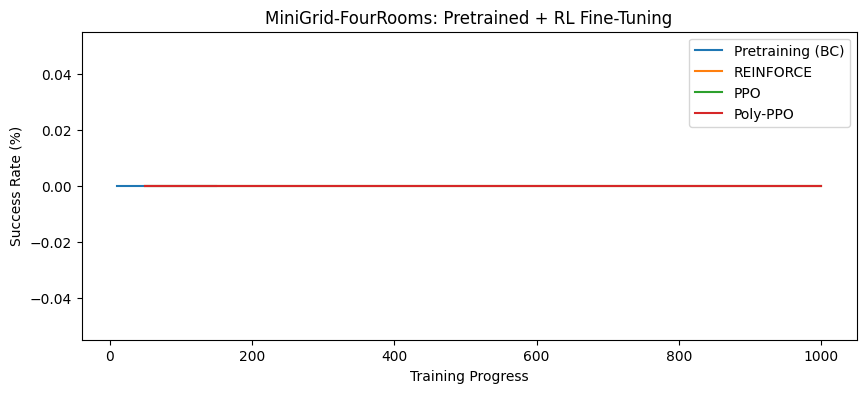

In [19]:
plt.figure(figsize=(10, 4))

if len(bc_hist) > 0:
    plt.plot(bc_hist["epoch"] * 10, bc_hist["success_rate"], label="Pretraining (BC)")
if len(reinforce_hist) > 0:
    plt.plot(reinforce_hist["step"], reinforce_hist["success_rate"], label="REINFORCE")
if len(ppo_hist) > 0:
    plt.plot(ppo_hist["step"] * 5, ppo_hist["success_rate"], label="PPO")
if len(polyppo_hist) > 0:
    plt.plot(polyppo_hist["step"] * 5, polyppo_hist["success_rate"], label="Poly-PPO")

plt.xlabel("Training Progress")
plt.ylabel("Success Rate (%)")
plt.title("MiniGrid-FourRooms: Pretrained + RL Fine-Tuning")
plt.legend()
plt.show()